Sriya Nistala

BL.EN.U4AIE23034

Speech Processing Lab 8

Assignment 7.1 — DFT vs DCT Energy Compaction

Part 1: Load audio and select 25 ms frame

In [12]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

# Load audio file
signal, sr = librosa.load('/content/drive/MyDrive/v2preach.wav', sr=None)

# Frame duration = 25 ms
frame_length = int(0.025 * sr)

# Take first frame
frame = signal[:frame_length]

# Apply Hamming window
window = np.hamming(frame_length)
windowed_frame = frame * window
print("Frame length :",frame_length)
print("Frame:",frame)
print("Window:", window)
print("Windowed Frame :",windowed_frame)

Frame length : 1102
Frame: [ 0.         -0.01037598 -0.00857544 ...  0.6513519   0.5801544
  0.4741211 ]
Window: [0.08       0.08000749 0.08002996 ... 0.08002996 0.08000749 0.08      ]
Windowed Frame : [ 0.         -0.00083016 -0.00068629 ...  0.05212767  0.0464167
  0.03792969]


Part 2: Compute DFT and DCT

In [13]:
from scipy.fftpack import dct

# DFT
dft = np.fft.fft(windowed_frame)
dft_magnitude = np.abs(dft)

# DCT
dct_coeffs = dct(windowed_frame, type=2, norm='ortho')
dct_magnitude = np.abs(dct_coeffs)

print("DFT Magnitude:")
print(dft_magnitude)
print("\nDCT Magnitude:")
print(dct_magnitude)

DFT Magnitude:
[ 47.15368312  71.81645632  29.38925313 ... 118.08697515  29.38925313
  71.81645632]

DCT Magnitude:
[1.42044631e+00 1.85910785e+00 8.71160496e-01 ... 1.40404049e-03
 3.65108835e-04 5.70584903e-04]


Part 3: Energy compaction comparison

In [14]:
import numpy as np

# Ensure magnitudes are real and valid
dft_mag = np.abs(dft)
dct_mag = np.abs(dct_coeffs)

# Remove NaN or Inf if any
dft_mag = np.nan_to_num(dft_mag)
dct_mag = np.nan_to_num(dct_mag)

# Energy calculation
total_energy_dft = np.sum(dft_mag ** 2)
total_energy_dct = np.sum(dct_mag ** 2)

# Number of coefficients to compare
N = 10

energy_dft_first = np.sum(dft_mag[:N] ** 2)
energy_dct_first = np.sum(dct_mag[:N] ** 2)

# Avoid division by zero
dft_ratio = energy_dft_first / total_energy_dft if total_energy_dft != 0 else 0
dct_ratio = energy_dct_first / total_energy_dct if total_energy_dct != 0 else 0

print("DFT Energy Ratio (first 10 coeffs):", dft_ratio)
print("DCT Energy Ratio (first 10 coeffs):", dct_ratio)

DFT Energy Ratio (first 10 coeffs): 0.4577643056679015
DCT Energy Ratio (first 10 coeffs): 0.7917100589687374


Part 4: Histogram plotting

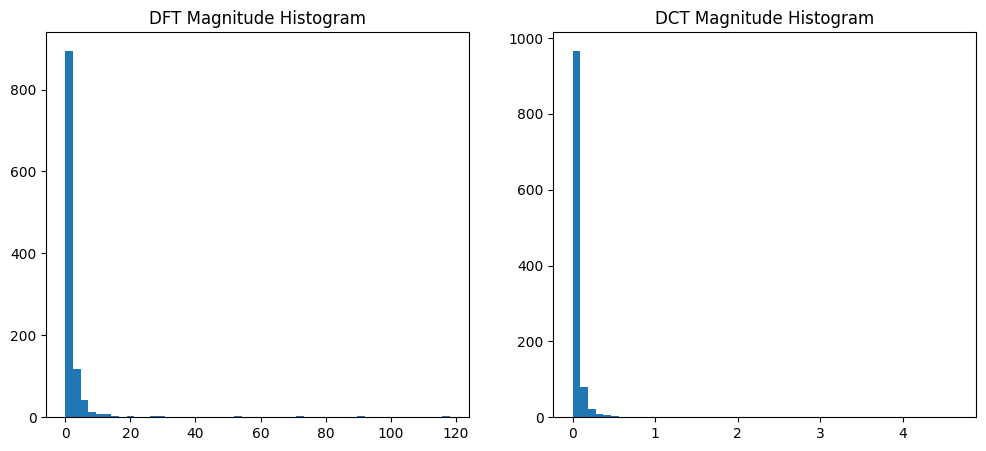

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(dft_magnitude, bins=50)
plt.title("DFT Magnitude Histogram")

plt.subplot(1, 2, 2)
plt.hist(dct_magnitude, bins=50)
plt.title("DCT Magnitude Histogram")

plt.show()

Assignment 7.2 — MFCC Extraction

Part 1: Compute and plot MFCC over time

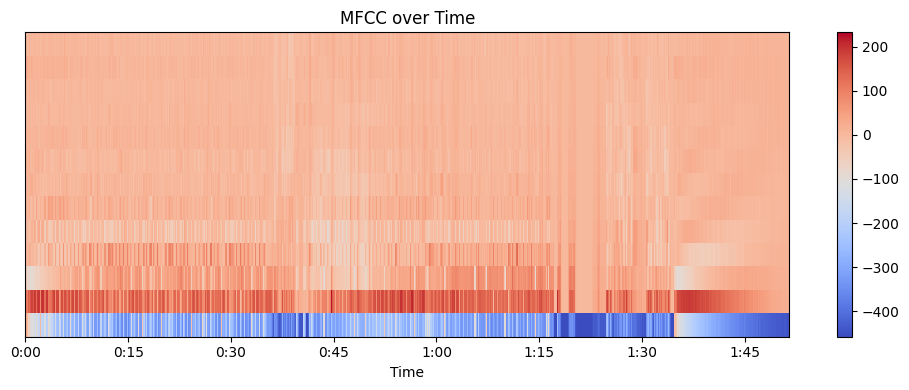

In [16]:
import librosa.display

# Extract MFCCs
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

# Plot MFCCs
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC over Time")
plt.tight_layout()
plt.show()

Part 2: Plot MFCCs of first two frames

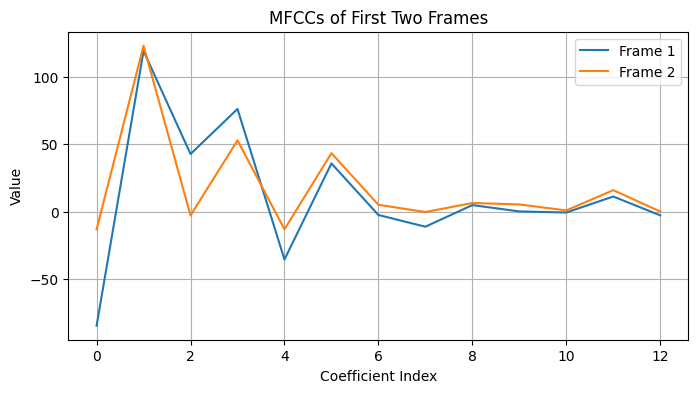

In [17]:
plt.figure(figsize=(8, 4))

plt.plot(mfccs[:, 0], label='Frame 1')
plt.plot(mfccs[:, 1], label='Frame 2')

plt.title("MFCCs of First Two Frames")
plt.xlabel("Coefficient Index")
plt.ylabel("Value")
plt.legend()
plt.grid()

plt.show()

Part 3: (Optional helper) Print MFCC values

In [18]:
print("MFCC - Frame 1:\n", mfccs[:, 0])
print("MFCC - Frame 2:\n", mfccs[:, 1])

MFCC - Frame 1:
 [-84.903244   119.49109     42.831184    76.346375   -35.64209
  35.850014    -2.5292845  -11.246153     4.832337     0.12987101
  -0.68173194  11.215383    -2.8090405 ]
MFCC - Frame 2:
 [-1.32385578e+01  1.23393875e+02 -2.88765597e+00  5.29963226e+01
 -1.32118111e+01  4.34431534e+01  5.08335495e+00 -3.26476097e-01
  6.38957739e+00  5.31814051e+00  8.76017630e-01  1.59425220e+01
  5.69835305e-02]
